# SurvBoost: Two-Year Survival Prediction in Oral Cancer

This notebook provides the experimental workflow for the SurvBoost
survival model described in the associated research study.

## Overview

The workflow includes:

1. Loading and preparing the analysis dataset
2. Training the SurvBoost model
3. Evaluating survival prediction performance
4. Computing the two-year survival probability
5. Performing SHAP-based model interpretation
6. Generating global and patient-level explanations

## Model

SurvBoost is a data-driven parametric survival gradient boosting
framework that learns patient-specific parameters for multiple
parametric survival distributions.

The final experimental configuration consists of:

- 5 Weibull heads
- 1 Log-Logistic head
- 1 Log-Normal head
- 5 Generalized Gamma heads
- 250 boosting estimators
- Maximum tree depth: 5
- Learning rate: 0.10
- Elastic-Net regularization strength: 0.01
- L1/L2 mixing ratio: 1
- ReLU head-weight activation

## Prediction target

The primary prediction target is:

P(T > 24 months | X)

where X represents the patient's clinical feature vector.

## Interpretability

Kernel SHAP is used to obtain:

- Global feature importance
- Patient-level feature contributions
- Individual explanations of two-year survival predictions

## Data availability

The SEER patient-level dataset is not included in this repository.
Researchers should obtain the appropriate SEER data independently
and prepare the analysis dataset according to the associated
manuscript.

In [1]:
# Install SHAP if not already installed
%pip install shap --quiet

Note: you may need to restart the kernel to use updated packages.


## 1.Imports

In [1]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from sklearn.model_selection import StratifiedKFold, train_test_split
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored, integrated_brier_score

import shap

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

sys.path.insert(0, os.getcwd())
from model import SurvBoost

In [2]:
DATA_PATH = Path(r"C:\Users\User\Downloads\Research\Surviavl_XAI\Dataset_with_encodings.csv")

TARGET_EVENT = "Vital status"
TARGET_TIME  = "Survival months"

ALL_FEATURES = [
    "Age", "Race", "Sex", "Marital status", "Grade",
    "T stage", "N stage", "M stage", "Radiation", "Surgery",
]

df = pd.read_csv(DATA_PATH)

X = df[ALL_FEATURES].copy()
y_df = df[[TARGET_EVENT, TARGET_TIME]].copy()

X_train_df, X_test_df, y_train_df, y_test_df = train_test_split(
    X, y_df,
    test_size=0.20,
    random_state=SEED,
    stratify=y_df[TARGET_EVENT],
)

## 2.Helper Functions

In [3]:
def to_surv_array(df):
    return Surv.from_arrays(
        event=df[TARGET_EVENT].astype(bool).to_numpy(),
        time=df[TARGET_TIME].astype(float).to_numpy(),
    )

def get_eval_times(y_ref, y_eval):
    lower = max(y_ref["time"].min(), y_eval["time"].min())
    upper = min(y_ref["time"].max(), y_eval["time"].max())
    return np.linspace(lower + 1e-3, upper - 1e-3, 100)

def evaluate_model(model, X_eval, y_eval, y_ref):
    eval_times = get_eval_times(y_ref, y_eval)

    surv_fns = model.predict_survival_function(X_eval)
    survs = np.array([fn(eval_times) for fn in surv_fns])
    survs = np.clip(survs, 1e-8, 1.0)
    survs = np.minimum.accumulate(survs, axis=1)

    risk = model.predict(X_eval)

    c_index = concordance_index_censored(
        y_eval["event"], y_eval["time"], risk
    )[0]

    ibs = integrated_brier_score(y_ref, y_eval, survs, eval_times)

    return {"c_index": c_index, "ibs": ibs}

In [4]:
# Combine time + event for better stratification
y_strat = pd.qcut(y_train_df[TARGET_TIME], 5, duplicates="drop").astype(str) + "_" + y_train_df[TARGET_EVENT].astype(str)

## 3. Extended FPBoost — Hyperparameters

Based on a **data-driven distribution selection** using the Nelson-Aalen estimator:

| Distribution | MSE vs Nelson-Aalen |
| --- | --- |
| **Generalized Gamma** | **0.001239** |
| **Log-Normal** | **0.001243** |
| Log-Logistic | 0.001465 |
| Weibull | 0.001726 |

We use **Weibull + LogNormal + Generalized Gamma + LogLogistic heads** .

In [5]:
PARAMS = {
    "weibull_heads": 5,
    "loglogistic_heads": 1,
    "lognormal_heads": 1,
    "gengamma_heads": 5,
    "n_estimators": 250,
    "learning_rate": 0.1,
    "max_depth": 5,
    "alpha": 0.001,
    "l1_ratio": 0.5,
    "uniform_heads": False,
    "heads_activation": "relu",
}

In [6]:
def build_model():
    return SurvBoost(
        weibull_heads=PARAMS["weibull_heads"],
        loglogistic_heads=PARAMS["loglogistic_heads"],
        lognormal_heads=PARAMS["lognormal_heads"],
        gengamma_heads=PARAMS["gengamma_heads"],
        n_estimators=PARAMS["n_estimators"],
        learning_rate=PARAMS["learning_rate"],
        max_depth=PARAMS["max_depth"],
        alpha=PARAMS["alpha"],
        l1_ratio=PARAMS["l1_ratio"],
        uniform_heads=PARAMS["uniform_heads"],
        heads_activation=PARAMS["heads_activation"],
        random_state=SEED,
    )

## 4.Startified K-fold CV

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = []

y_train = to_surv_array(y_train_df)

for fold, (tr_idx, val_idx) in enumerate(cv.split(X_train_df, y_strat), 1):

    X_tr = X_train_df.iloc[tr_idx].values.astype(np.float32)
    X_val = X_train_df.iloc[val_idx].values.astype(np.float32)

    y_tr = to_surv_array(y_train_df.iloc[tr_idx])
    y_val = to_surv_array(y_train_df.iloc[val_idx])

    model = build_model()
    model.fit(X_tr, y_tr)

    # IMPORTANT FIX → use global y_train
    metrics = evaluate_model(model, X_val, y_val, y_tr)

    print(f"Fold {fold}: C={metrics['c_index']:.4f}, IBS={metrics['ibs']:.4f}")
    cv_results.append(metrics)

cv_df = pd.DataFrame(cv_results)

cv_c = cv_df["c_index"].mean()
cv_ibs = cv_df["ibs"].mean()

print("\nCV Results:")
print(f"C-Index: {cv_c:.4f}")
print(f"IBS: {cv_ibs:.4f}")

Fold 1: C=0.7290, IBS=0.1662
Fold 2: C=0.7480, IBS=0.1697
Fold 3: C=0.7397, IBS=0.1672
Fold 4: C=0.7306, IBS=0.1663
Fold 5: C=0.7424, IBS=0.1650

CV Results:
C-Index: 0.7379
IBS: 0.1669


## 5.Final model training and Test evaluation

In [8]:
X_train_np = X_train_df.values.astype(np.float32)
X_test_np  = X_test_df.values.astype(np.float32)

y_train = to_surv_array(y_train_df)
y_test  = to_surv_array(y_test_df)

final_model = build_model()
final_model.fit(X_train_np, y_train)

test_metrics = evaluate_model(final_model, X_test_np, y_test, y_train)

print("\nFINAL RESULTS")
print(f"CV C-Index: {cv_c:.4f}")
print(f"CV IBS: {cv_ibs:.4f}")
print(f"Test C-Index: {test_metrics['c_index']:.4f}")
print(f"Test IBS: {test_metrics['ibs']:.4f}")


FINAL RESULTS
CV C-Index: 0.7379
CV IBS: 0.1669
Test C-Index: 0.7465
Test IBS: 0.1626


In [9]:
test_metrics = evaluate_model(
    final_model,
    X_test_np,
    y_test,
    y_train
)

print("\n" + "=" * 50)
print("FINAL TEST-SET PERFORMANCE")
print("=" * 50)

print(f"Test C-Index : {test_metrics['c_index']:.4f}")
print(f"Test IBS      : {test_metrics['ibs']:.4f}")

print("\nDevelopment Cross-Validation Performance")
print(f"CV C-Index   : {cv_c:.4f}")
print(f"CV IBS       : {cv_ibs:.4f}")


FINAL TEST-SET PERFORMANCE
Test C-Index : 0.7465
Test IBS      : 0.1626

Development Cross-Validation Performance
CV C-Index   : 0.7379
CV IBS       : 0.1669


In [10]:
final_results = pd.DataFrame({
    "Metric": [
        "5-Fold CV C-Index",
        "5-Fold CV IBS",
        "Final Test C-Index",
        "Final Test IBS"
    ],
    "Value": [
        cv_c,
        cv_ibs,
        test_metrics["c_index"],
        test_metrics["ibs"]
    ]
})

print("\nFinal Evaluation Summary")
print(final_results.to_string(index=False))

final_results.to_csv(
    "SurvBoost_final_evaluation_results.csv",
    index=False
)


Final Evaluation Summary
            Metric    Value
 5-Fold CV C-Index 0.737922
     5-Fold CV IBS 0.166863
Final Test C-Index 0.746514
    Final Test IBS 0.162590


## 6. SHAP Analysis — Overall Feature Importance

Using **SHAP KernelExplainer** (model-agnostic) to compute Shapley values for
the prediction function `P(T > 24 months | X)`.

This produces the **overall feature importance bar plot** showing which features
contribute most to the model's predictions across all patients.

In [ ]:
def predict_24m(X):
    X = np.atleast_2d(X).astype(np.float32)
    surv = final_model.predict_survival_function(X)
    return np.array([fn(24.0) for fn in surv])

background = shap.kmeans(X_train_np, 50)
explainer = shap.KernelExplainer(predict_24m, background)

X_explain = X_test_np[:100]
shap_values = explainer.shap_values(X_explain)

  0%|          | 0/100 [00:00<?, ?it/s]

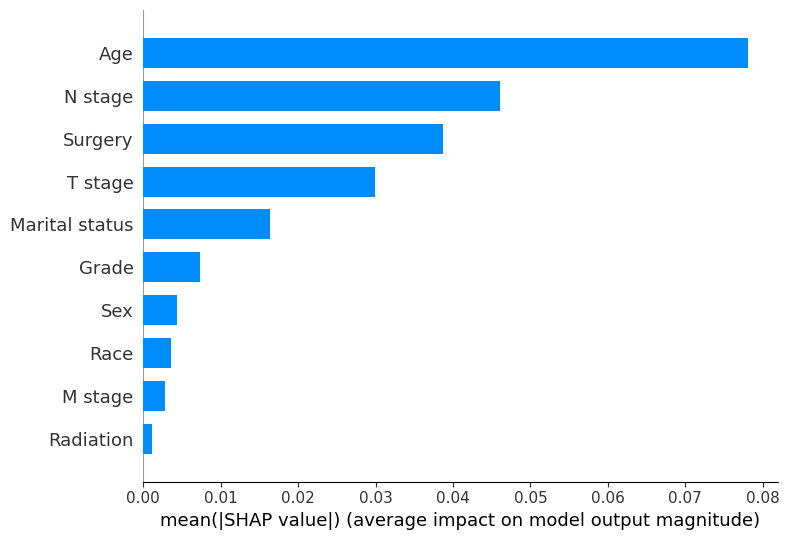

In [ ]:
shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=ALL_FEATURES,
    plot_type="bar"
)

## 7. New Patient Prediction + Patient-Specific SHAP

Given a new patient's features, predict `P(T > 24 months)` and show a **SHAP bar plot**
illustrating which features push the prediction **higher** (green) or **lower** (red).

In [ ]:
# ============================================================
# New Patient Features
# ============================================================
new_patient = {
    "Age":            25,
    "Race":           1,
    "Sex":            0,
    "Marital status": 1,
    "Grade":          1,
    "T stage":        1,
    "N stage":        1,
    "M stage":        0,
    "Radiation":      0,
    "Surgery":        1,
}

# Build patient feature array
patient_df = pd.DataFrame([new_patient])[ALL_FEATURES]
X_patient  = patient_df.values.astype(np.float32)

# ============================================================
# Predict P(T > 24 months)
# ============================================================
#prob_24m = predict_survival_24m(X_patient)[0]
prob_24m = predict_24m(X_patient)[0]
print("=" * 60)
print("          NEW PATIENT — 2-YEAR SURVIVAL PREDICTION")
print("=" * 60)
for key, value in new_patient.items():
    print(f"  {key:20s}: {value}")
print()
print(f"  >>> Predicted P(T > 24 months) = {prob_24m:.4f}  ({prob_24m:.2%})")
print("=" * 60)

          NEW PATIENT — 2-YEAR SURVIVAL PREDICTION
  Age                 : 25
  Race                : 1
  Sex                 : 0
  Marital status      : 1
  Grade               : 1
  T stage             : 1
  N stage             : 1
  M stage             : 0
  Radiation           : 0
  Surgery             : 1

  >>> Predicted P(T > 24 months) = 0.9497  (94.97%)


In [ ]:
# ============================================================
# Compute SHAP values for new patient
# ============================================================
print("Computing SHAP values for the new patient...")
patient_shap_values = explainer.shap_values(X_patient)
shap_vals = patient_shap_values[0]  # shape: (n_features,)

print("\nSHAP values for each feature:")
print("-" * 50)
for feat, sv in zip(ALL_FEATURES, shap_vals):
    direction = "↑ Positive" if sv > 0 else "↓ Negative"
    print(f"  {feat:20s}: {sv:+.6f}  ({direction})")
print(f"\n  Base value (expected):  {explainer.expected_value:.4f}")
print(f"  Sum of SHAP values:    {shap_vals.sum():+.6f}")
print(f"  Base + SHAP sum:       {explainer.expected_value + shap_vals.sum():.4f}")
print(f"  Actual prediction:     {prob_24m:.4f}")

Computing SHAP values for the new patient...


  0%|          | 0/1 [00:00<?, ?it/s]


SHAP values for each feature:
--------------------------------------------------
  Age                 : +0.155767  (↑ Positive)
  Race                : +0.010818  (↑ Positive)
  Sex                 : -0.005546  (↓ Negative)
  Marital status      : +0.002730  (↑ Positive)
  Grade               : -0.001716  (↓ Negative)
  T stage             : -0.063139  (↓ Negative)
  N stage             : -0.076755  (↓ Negative)
  M stage             : +0.008374  (↑ Positive)
  Radiation           : -0.138552  (↓ Negative)
  Surgery             : -0.187689  (↓ Negative)

  Base value (expected):  0.8277
  Sum of SHAP values:    -0.295708
  Base + SHAP sum:       0.5319
  Actual prediction:     0.5319


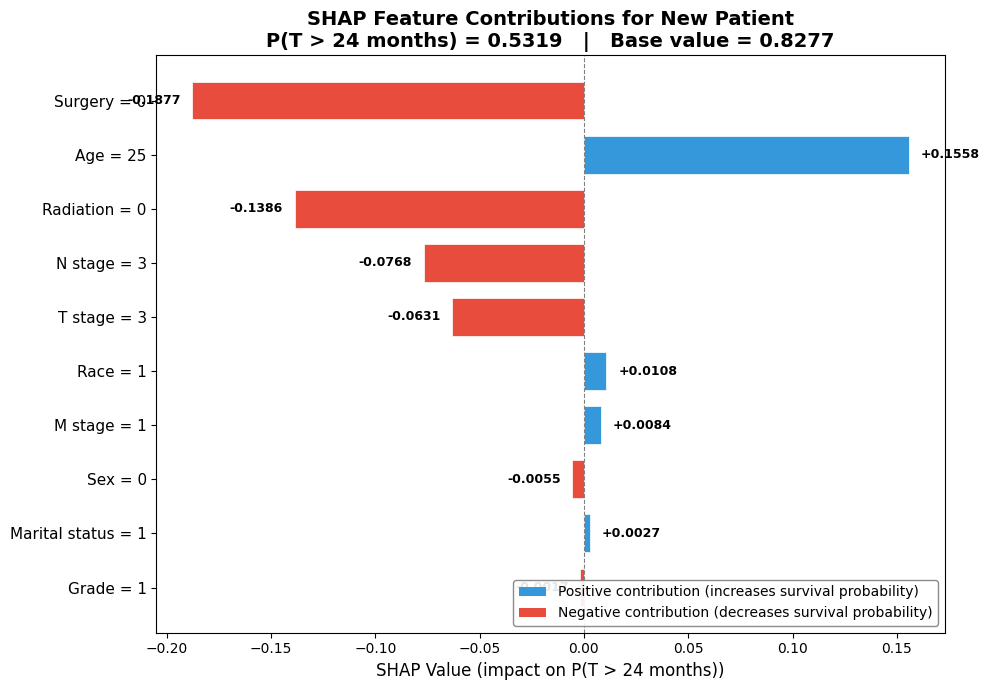


Plot saved as 'shap_patient_feature_contributions.png'


In [ ]:
# ============================================================
# PATIENT-SPECIFIC SHAP BAR PLOT
# Green = feature increases P(T>24m) (positive contribution)
# Red   = feature decreases P(T>24m) (negative contribution)
# ============================================================
sorted_idx  = np.argsort(np.abs(shap_vals))
sorted_vals = shap_vals[sorted_idx]
sorted_names = [ALL_FEATURES[i] for i in sorted_idx]
sorted_feat_vals = [new_patient[ALL_FEATURES[i]] for i in sorted_idx]
colors = ["#3498db" if v > 0 else "#e74c3c" for v in sorted_vals]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    range(len(sorted_vals)),
    sorted_vals,
    color=colors,
    edgecolor="white",
    linewidth=0.5,
    height=0.7,
)

# Add value labels on bars
max_abs = max(abs(sorted_vals.min()), abs(sorted_vals.max())) if len(sorted_vals) > 0 else 1
offset = max_abs * 0.03
for i, (bar, val) in enumerate(zip(bars, sorted_vals)):
    label_x = val + offset if val >= 0 else val - offset
    ha = "left" if val >= 0 else "right"
    ax.text(label_x, i, f"{val:+.4f}", va="center", ha=ha, fontsize=9, fontweight="bold")

# Y-axis: feature name = value
y_labels = [f"{name} = {fv}" for name, fv in zip(sorted_names, sorted_feat_vals)]
ax.set_yticks(range(len(y_labels)))
ax.set_yticklabels(y_labels, fontsize=11)
ax.set_xlabel("SHAP Value (impact on P(T > 24 months))", fontsize=12)

ax.set_title(
    f"SHAP Feature Contributions for New Patient\n"
    f"P(T > 24 months) = {prob_24m:.4f}   |   Base value = {explainer.expected_value:.4f}",
    fontsize=14,
    fontweight="bold",
)

# Zero line
ax.axvline(x=0, color="gray", linewidth=0.8, linestyle="--")

# Legend
legend_elements = [
    Patch(facecolor="#3498db", edgecolor="none",
          label="Positive contribution (increases survival probability)"),
    Patch(facecolor="#e74c3c", edgecolor="none",
          label="Negative contribution (decreases survival probability)"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=10,
          framealpha=0.9, edgecolor="gray")

plt.tight_layout()
plt.savefig("shap_patient_feature_contributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved as 'shap_patient_feature_contributions.png'")
